In [2]:
from pathlib import Path

PROJECT_ROOT = Path("/content/fashion-retrieval")

folders = [
    "models",
    "indexer",
    "retriever",
    "utils",
    "index_store",
    "evaluation",
    "notebooks"
]

for folder in folders:
    (PROJECT_ROOT / folder).mkdir(parents=True, exist_ok=True)

print("Project structure created!")

Project structure created!


In [3]:
import sys

PROJECT_ROOT = "/content/fashion-retrieval"

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

print(sys.path[-1])

/content/fashion-retrieval


In [4]:
!pip install -q \
transformers \
accelerate \
sentencepiece \
timm \
faiss-gpu \
opencv-python \
scikit-learn \
matplotlib \
pillow \
tqdm \
numpy \
pandas \
scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.9/134.9 MB 8.7 MB/s eta 0:00:00


In [5]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [7]:
from zipfile import ZipFile
from pathlib import Path

ZIP_PATH = Path("/content/val_test2020.zip")
EXTRACT_PATH = Path("/content/fashionpedia")

EXTRACT_PATH.mkdir(parents=True, exist_ok=True)

with ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

print("Dataset extracted successfully.")

Dataset extracted successfully.


In [8]:
from pathlib import Path

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}

image_paths = []

for ext in IMAGE_EXTENSIONS:
    image_paths.extend(EXTRACT_PATH.rglob(f"*{ext}"))
    image_paths.extend(EXTRACT_PATH.rglob(f"*{ext.upper()}"))

print(f"Total images found: {len(image_paths)}")

if len(image_paths) > 0:
    print("\nFirst five images:")
    for img in image_paths[:5]:
        print(img)

Total images found: 3200

First five images:
/content/fashionpedia/test/0ef685358bc959847a46c299322bafa0.jpg
/content/fashionpedia/test/d0cd68ece3aa076ba4f3855d99b96767.jpg
/content/fashionpedia/test/5d2a983e1bcdce687150ce6115212283.jpg
/content/fashionpedia/test/ea684c41ca8adc3cceea67b19d6ea659.jpg
/content/fashionpedia/test/82578e153eb6a88d81bfaa437946049b.jpg


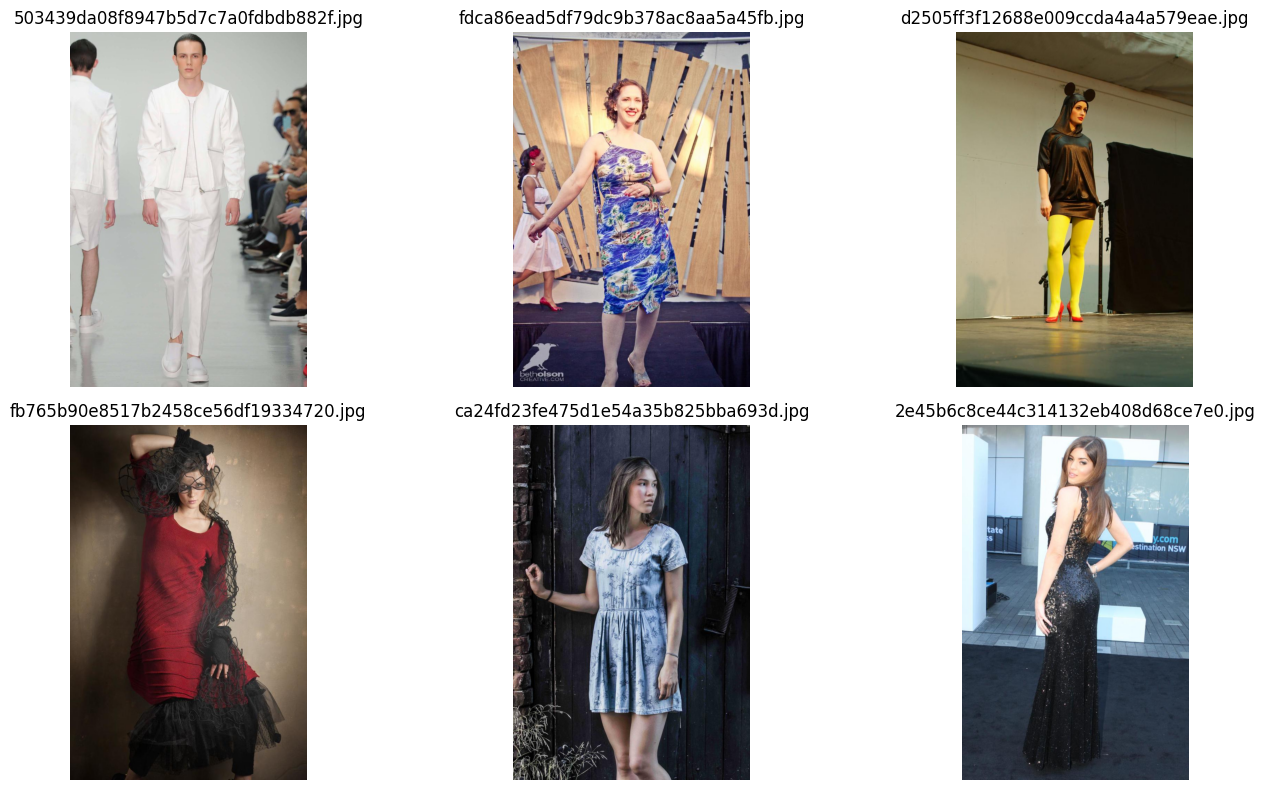

In [9]:
import matplotlib.pyplot as plt
from PIL import Image
import random

random.seed(42)

sample_images = random.sample(image_paths, 6)

plt.figure(figsize=(15, 8))

for i, img_path in enumerate(sample_images):
    plt.subplot(2, 3, i + 1)
    img = Image.open(img_path)
    plt.imshow(img)
    plt.title(img_path.name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
from PIL import Image

valid_images = []
corrupt_images = []

for img_path in image_paths:
    try:
        with Image.open(img_path) as img:
            img.verify()
        valid_images.append(img_path)
    except Exception:
        corrupt_images.append(img_path)

print("=" * 50)
print("Valid Images   :", len(valid_images))
print("Corrupt Images :", len(corrupt_images))
print("=" * 50)

Valid Images   : 3200
Corrupt Images : 0


In [11]:
import random

SEED = 42
SAMPLE_SIZE = 800

random.seed(SEED)

sampled_images = random.sample(valid_images, SAMPLE_SIZE)

print(f"Sampled {len(sampled_images)} images.")

print("\nFirst five sampled images:")

for img in sampled_images[:5]:
    print(img.name)

Sampled 800 images.

First five sampled images:
503439da08f8947b5d7c7a0fdbdb882f.jpg
fdca86ead5df79dc9b378ac8aa5a45fb.jpg
d2505ff3f12688e009ccda4a4a579eae.jpg
fb765b90e8517b2458ce56df19334720.jpg
ca24fd23fe475d1e54a35b825bba693d.jpg


In [13]:
from transformers import CLIPProcessor, CLIPModel
import torch

MODEL_PATH = "/content/drive/MyDrive/FASHION_CLIP_MODEL"

processor = CLIPProcessor.from_pretrained(MODEL_PATH)
model = CLIPModel.from_pretrained(MODEL_PATH)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
model.eval()

print(type(model))
print(device)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

<class 'transformers.models.clip.modeling_clip.CLIPModel'>
cuda


In [14]:
sample_image = sampled_images[0]

from PIL import Image

image = Image.open(sample_image).convert("RGB")

inputs = processor(images=image, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model.get_image_features(**inputs)

print(type(outputs))

if hasattr(outputs, "keys"):
    print(outputs.keys())
    print(outputs.pooler_output.shape)

<class 'transformers.modeling_outputs.BaseModelOutputWithPooling'>
odict_keys(['last_hidden_state', 'pooler_output'])
torch.Size([1, 512])


In [15]:
from models.vision_encoder import VisionEncoder
import torch

MODEL_PATH = "/content/drive/MyDrive/FASHION_CLIP_MODEL"

encoder = VisionEncoder(MODEL_PATH)

embedding = encoder.encode_image(sampled_images[0])

print(type(embedding))
print(embedding.shape)
print(torch.norm(embedding))

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

<class 'torch.Tensor'>
torch.Size([512])
tensor(1.0000)


In [16]:
embeddings = encoder.encode_images(sampled_images[:2])

print(embeddings.shape)
print(torch.norm(embeddings, dim=1))

torch.Size([2, 512])
tensor([1.0000, 1.0000])


In [17]:
from indexer.build_embeddings import EmbeddingBuilder

MODEL_PATH = "/content/drive/MyDrive/FASHION_CLIP_MODEL"

builder = EmbeddingBuilder(
    model_path=MODEL_PATH,
    batch_size=32,
)

embeddings = builder.build(sampled_images)

print(embeddings.shape)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

(800, 512)


In [18]:
#save embeddings for 800 images
builder.save(
    embeddings,
    "/content/fashion-retrieval/index_store/fashionclip_embeddings.npy"
)

BLIP

In [21]:
!pip install -q transformers accelerate sentencepiece

In [23]:
from transformers import BlipProcessor, BlipForConditionalGeneration
import torch

MODEL_PATH = "/content/drive/MyDrive/BLIP_MODEL"

processor = BlipProcessor.from_pretrained(MODEL_PATH)
model = BlipForConditionalGeneration.from_pretrained(MODEL_PATH)

device = "cuda" if torch.cuda.is_available() else "cpu"

model.to(device)
model.eval()

print("BLIP loaded successfully!")

Loading weights:   0%|          | 0/471 [00:00<?, ?it/s]

BLIP loaded successfully!


In [24]:
from indexer.caption_generator import CaptionGenerator

BLIP_PATH = "/content/drive/MyDrive/BLIP_MODEL"

caption_model = CaptionGenerator(BLIP_PATH)

caption = caption_model.generate_caption(sampled_images[0])

print(caption)

Loading weights:   0%|          | 0/471 [00:00<?, ?it/s]

a model walks the runway at the person show during london fashion week


In [25]:
captions = caption_model.generate_captions(sampled_images[:3])

for i, caption in enumerate(captions):
    print(f"Image {i+1}:")
    print(caption)
    print("-" * 60)

Image 1:
a model walks the runway at the person show during london fashion week
------------------------------------------------------------
Image 2:
a woman in a dress standing on a stage
------------------------------------------------------------
Image 3:
a woman in yellow tights and a black top
------------------------------------------------------------


clothing parser


In [26]:
!pip install -q spacy
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 108.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [32]:
from indexer.clothing_parser import ClothingParser

parser = ClothingParser()

caption = "a woman in yellow tights and a black top"

result = parser.parse(caption)

print(result)

{'caption': 'a woman in yellow tights and a black top', 'people': ['woman'], 'style': [], 'garments': [{'type': 'tights', 'color': 'yellow'}, {'type': 'top', 'color': 'black'}]}


In [31]:
#testing
captions = [
    "a model walks the runway at the person show during london fashion week",
    "a woman in a dress standing on a stage",
    "a woman in yellow tights and a black top",
    "a man wearing a white shirt with a red tie",
    "a man wearing a white formal shirt and a dark blue tie"
]

for caption in captions:
    print("=" * 70)
    print(caption)
    print(parser.parse(caption))

a model walks the runway at the person show during london fashion week
{'caption': 'a model walks the runway at the person show during london fashion week', 'people': ['model', 'person'], 'style': [], 'garments': []}
a woman in a dress standing on a stage
{'caption': 'a woman in a dress standing on a stage', 'people': ['woman'], 'style': [], 'garments': [{'type': 'dress', 'color': None}]}
a woman in yellow tights and a black top
{'caption': 'a woman in yellow tights and a black top', 'people': ['woman'], 'style': [], 'garments': [{'type': 'tights', 'color': 'yellow'}, {'type': 'top', 'color': 'black'}]}
a man wearing a white shirt with a red tie
{'caption': 'a man wearing a white shirt with a red tie', 'people': ['man'], 'style': [], 'garments': [{'type': 'shirt', 'color': 'white'}, {'type': 'tie', 'color': 'red'}]}
a man wearing a white formal shirt and a dark blue tie
{'caption': 'a man wearing a white formal shirt and a dark blue tie', 'people': ['man'], 'style': ['formal'], 'garmen

In [33]:
from indexer.clothing_parser import ClothingParser

parser = ClothingParser()

tests = [

    "a woman in yellow tights and a black top",

    "a man wearing a white formal shirt and a dark blue tie",

    "a woman wearing a black leather jacket",

    "a woman wearing a light pink floral dress",

    "a man wearing blue denim jeans",

    "a person in a bright yellow raincoat"

]

for t in tests:

    print("="*80)
    print(t)
    print(parser.parse(t))

a woman in yellow tights and a black top
{'caption': 'a woman in yellow tights and a black top', 'people': ['woman'], 'style': [], 'garments': [{'type': 'tights', 'color': 'yellow'}, {'type': 'top', 'color': 'black'}]}
a man wearing a white formal shirt and a dark blue tie
{'caption': 'a man wearing a white formal shirt and a dark blue tie', 'people': ['man'], 'style': ['formal'], 'garments': [{'type': 'shirt', 'color': 'white'}, {'type': 'tie', 'color': 'blue'}]}
a woman wearing a black leather jacket
{'caption': 'a woman wearing a black leather jacket', 'people': ['woman'], 'style': [], 'garments': [{'type': 'jacket', 'color': 'black'}]}
a woman wearing a light pink floral dress
{'caption': 'a woman wearing a light pink floral dress', 'people': ['woman'], 'style': [], 'garments': [{'type': 'dress', 'color': 'pink'}]}
a man wearing blue denim jeans
{'caption': 'a man wearing blue denim jeans', 'people': ['man'], 'style': [], 'garments': [{'type': 'jeans', 'color': 'blue'}]}
a person i

In [52]:
import importlib

import indexer.scene_classifier

importlib.reload(indexer.scene_classifier)

from indexer.scene_classifier import SceneClassifier

In [49]:
from indexer.scene_classifier import SceneClassifier

classifier = SceneClassifier(
    "/content/drive/MyDrive/PLACES365_MODEL"
)

result = classifier.predict(sampled_images[0])

print(result)

{'scene': 'other', 'raw_scene': 'clean room', 'confidence': 0.7752, 'top5': [('clean room', 0.7752), ('martial arts gym', 0.1269), ('dressing room', 0.0184), ('hospital room', 0.0153), ('nursing home', 0.0101)]}


In [41]:
for image in sampled_images[:5]:

    print("="*80)

    print(classifier.predict(image))

{'scene': 'martial arts gym', 'confidence': 0.5359, 'top5': [('martial arts gym', 0.5359), ('clean room', 0.4284), ('nursing home', 0.0058), ('biology laboratory', 0.004), ('beauty salon', 0.0035)]}
{'scene': 'locker room', 'confidence': 0.6801, 'top5': [('locker room', 0.6801), ('dressing room', 0.0694), ('art studio', 0.0154), ('fire escape', 0.0144), ('elevator/door', 0.0126)]}
{'scene': 'stage/indoor', 'confidence': 0.2403, 'top5': [('stage/indoor', 0.2403), ('ballroom', 0.1439), ('arena/performance', 0.0723), ('stage/outdoor', 0.0607), ('television studio', 0.0482)]}
{'scene': 'dressing room', 'confidence': 0.8058, 'top5': [('dressing room', 0.8058), ('elevator/door', 0.1488), ('elevator lobby', 0.0261), ('beauty salon', 0.0054), ('stage/indoor', 0.0026)]}
{'scene': 'elevator/door', 'confidence': 0.596, 'top5': [('elevator/door', 0.596), ('elevator lobby', 0.2408), ('barndoor', 0.0739), ('bank vault', 0.0299), ('dressing room', 0.0152)]}


In [51]:
result = classifier.predict(sampled_images[0])

print(result.keys())

dict_keys(['scene', 'raw_scene', 'confidence', 'top5'])


In [50]:
from config import PLACES365_MODEL_PATH

classifier = SceneClassifier(PLACES365_MODEL_PATH)

result = classifier.predict(sampled_images[0])

print(result)

{'scene': 'other', 'raw_scene': 'clean room', 'confidence': 0.7752, 'top5': [('clean room', 0.7752), ('martial arts gym', 0.1269), ('dressing room', 0.0184), ('hospital room', 0.0153), ('nursing home', 0.0101)]}


In [54]:
from indexer.scene_resolver import SceneResolver

resolver = SceneResolver()

scene = resolver.resolve(
    caption,
    classifier.predict(sampled_images[0])
)

scene

{'normalized': 'runway', 'raw': 'runway', 'source': 'blip', 'confidence': 1.0}

Metadata

In [66]:
import importlib
import indexer.metadata_builder

importlib.reload(indexer.metadata_builder)

from indexer.metadata_builder import MetadataBuilder

In [67]:
#metadata testing
from indexer.metadata_builder import MetadataBuilder
from indexer.scene_resolver import SceneResolver

resolver = SceneResolver()

# Generate caption
caption = caption_model.generate_caption(
    sampled_images[0]
)

# Parse clothing attributes
clothing = parser.parse(caption)

# Predict scene using Places365
places_scene = classifier.predict(
    sampled_images[0]
)

# Resolve final scene using BLIP + Places365
resolved_scene = resolver.resolve(
    caption,
    places_scene
)

# Build metadata
metadata = MetadataBuilder.build(
    image_id=0,
    image_path=sampled_images[0],
    caption=caption,
    clothing=clothing,
    scene=resolved_scene
)

metadata

{'image_id': 0,
 'image_name': '503439da08f8947b5d7c7a0fdbdb882f.jpg',
 'image_path': '/content/fashionpedia/test/503439da08f8947b5d7c7a0fdbdb882f.jpg',
 'embedding_index': 0,
 'caption': 'a model walks the runway at the person show during london fashion week',
 'scene': {'normalized': 'runway',
  'raw': 'runway',
  'source': 'blip',
  'confidence': 1.0},
 'people': ['model', 'person'],
 'garments': [],
 'tags': ['fashion_week', 'model', 'person', 'runway']}

builder

In [74]:
from indexer.build_index import main

embeddings, metadata = main(sampled_images)

Loading Models...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/471 [00:00<?, ?it/s]

✓ Vision Encoder Loaded
✓ BLIP Loaded
✓ Clothing Parser Loaded
✓ Places365 Loaded
✓ Scene Resolver Loaded

Processing 800 Images


Building Index: 100%|██████████| 25/25 [03:49<00:00,  9.19s/it]


Finalizing Outputs...

Index Building Complete
Images Indexed    : 800
Embeddings Shape  : (800, 512)
Metadata Saved    : /content/fashion-retrieval/index_store/metadata.json
Embeddings Saved  : /content/fashion-retrieval/index_store/fashionclip_embeddings.npy


In [75]:
for i in range(5):
    print("=" * 80)
    print(metadata[i])

{'image_id': 0, 'image_name': '503439da08f8947b5d7c7a0fdbdb882f.jpg', 'image_path': '/content/fashionpedia/test/503439da08f8947b5d7c7a0fdbdb882f.jpg', 'embedding_index': 0, 'caption': 'a model walks the runway at the person show during london fashion week', 'scene': {'normalized': 'runway', 'raw': 'runway', 'source': 'blip', 'confidence': 1.0}, 'people': ['model', 'person'], 'garments': [], 'tags': ['fashion_week', 'model', 'person', 'runway']}
{'image_id': 1, 'image_name': 'fdca86ead5df79dc9b378ac8aa5a45fb.jpg', 'image_path': '/content/fashionpedia/test/fdca86ead5df79dc9b378ac8aa5a45fb.jpg', 'embedding_index': 1, 'caption': 'a woman in a dress standing on a stage', 'scene': {'normalized': 'sports', 'raw': 'locker room', 'source': 'places365', 'confidence': 0.2264}, 'people': ['woman'], 'garments': [{'type': 'dress', 'color': None}], 'tags': ['dress', 'sports', 'woman']}
{'image_id': 2, 'image_name': 'd2505ff3f12688e009ccda4a4a579eae.jpg', 'image_path': '/content/fashionpedia/test/d250

Faiss Index

In [76]:
import numpy as np

from config import (
    EMBEDDINGS_PATH,
    FAISS_INDEX_PATH
)

from indexer.faiss_builder import FAISSBuilder

In [77]:
embeddings = np.load(
    EMBEDDINGS_PATH
)

builder = FAISSBuilder()

index = builder.build(
    embeddings
)

builder.save(
    FAISS_INDEX_PATH
)

print(index)

<faiss.swigfaiss.IndexFlatIP; proxy of <Swig Object of type 'faiss::IndexFlatIP *' at 0x7e96d8b353f0> >


In [78]:
print(index.ntotal)

800
